# Figure S11: Correlations between all model parameters describing inter-run and run durations modulations during sessions and across actions costs

!!!!!!! correlations need high (500000 done 1h, 1000000 maybe) iters to remove noise and have similar pvalues when comparing X~Y vs Y~X

## setup and imports

In [13]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fnmatch

from scipy.cluster.hierarchy import dendrogram, linkage, _plot_dendrogram
from scipy.cluster import hierarchy
import matplotlib.colors as mcolors

import warnings
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [14]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [15]:

names = ['alpha_0', 'alpha_t', 'alpha_u', 
         'gamma_0', 'gamma_t', 'gamma_u', 
         'mu_0', 'mu_t', 'mu_u', 
         'sigma_0', 'sigma_t', 'sigma_u']

alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u]


# # put all vars in a single dataframe
# l = []
# for animal in intact_rats:
#     cond = '120'
#     _ = pd.DataFrame([[var[animal][cond] for var in vars]], columns=names)
#     _["animal"] = animal
#     _["condition"] = cond
#     l.append(_)
# df = pd.concat(l)


# S11B Correlation between parameters
(Need to define correlation first, and make S11A correlation matrix with S11B correlations)

mu_t vs alpha_t: p=0.0002, r=0.7087, r²=0.5023
0.013198680131986803
alpha_t vs mu_t: p=0.0009, r=0.7087, r²=0.5023
0.059394060593940604


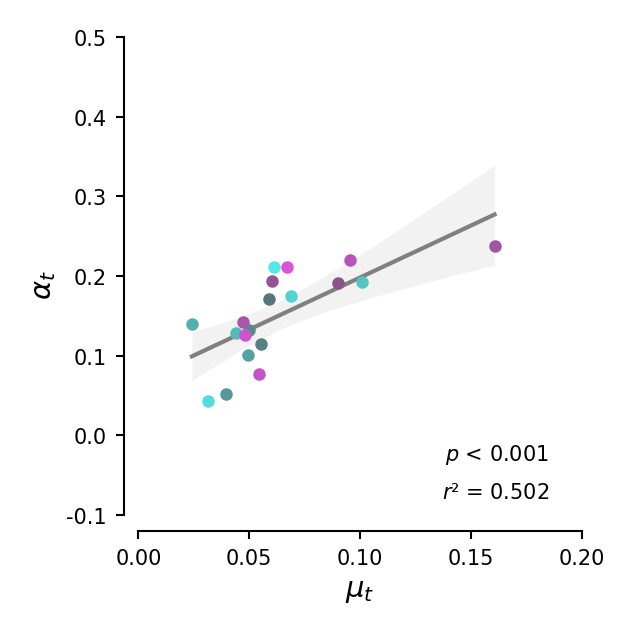

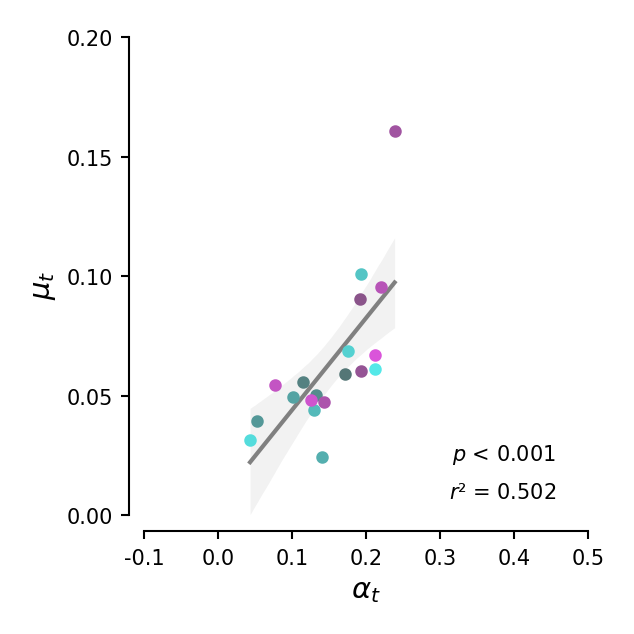

In [16]:
from random import seed


def Figure6K(var1, var2, name1, name2, ax=None, animal_list=intact_rats,
             bonferroni_correction=1, seed=42, plot_params=GENERAL_PLOT_PARAMS,
             force_p=None  # reuse pvals from previous calculations to avoid randomness-induced variability
             ):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    x, y = [], []
    cond = '120'
    for animal in animal_list:
        ax.scatter(var1[animal][cond], var2[animal][cond], color=rat_markers[animal][0], zorder=10, s=4, marker=rat_markers[animal][1])
        x.append(var1[animal][cond])
        y.append(var2[animal][cond])
        # print(animal, lesion_sizes[animal]['DS'], effort_sensitivity_0[animal])

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # calculate confidence intervals for fitted line
    xi = np.linspace(np.min(x), np.max(x), 100)
    ps = np.random.multivariate_normal(p, cov, 10000)
    ysample = np.asarray([f(xi, *pi) for pi in ps])
    lower = np.percentile(ysample, 2.5, axis=0)
    upper = np.percentile(ysample, 97.5, axis=0)

    # plot the regression and confidence intervals
    y_fit = np.poly1d(p)(xi)
    ax.plot(xi, y_fit, color='gray', zorder=1)
    ax.fill_between(xi, lower, upper, color='gray', alpha=.1, zorder=0, lw=0)


    # permutation test for correlation pval
    # r_obs = np.corrcoef(x, y)[0, 1]

    rng = np.random.default_rng(seed)

    # n_perm = 10000
    # r_perm = np.empty(n_perm)
    # for i in range(n_perm):
    #     y_perm = rng.permutation(y)
    #     r_perm[i] = np.corrcoef(x, y_perm)[0, 1]

    # p_value = np.mean(np.abs(r_perm) >= np.abs(r_obs))

    # r = r_obs
    # r_squared = r_obs ** 2






    x = np.asarray(x)
    y = np.asarray(y)

    r_obs = np.corrcoef(x, y)[0, 1]

    if force_p is not None:
        if isinstance(force_p, dict):
            # reuse previous pvals to avoid randomness-induced variability
            p_value = force_p[name1][name2]
        elif isinstance(force_p, (float, int)):
            p_value = force_p

    else:
        # n_perm = 500000
        n_perm = 10000

        r_perm = np.empty(n_perm)

        idx = np.arange(len(x))
        for i in range(n_perm):
            perm = rng.permutation(idx)
            r_perm[i] = np.corrcoef(x, y[perm])[0, 1]

        p_value = (np.sum(np.abs(r_perm) >= np.abs(r_obs)) + 1) / (n_perm + 1)

    r = r_obs
    r_squared = r_obs ** 2


    # pvalue annotation
    _p = min(1, p_value * bonferroni_correction)
    ax.annotate(f"{stars(_p)}", xy=(.9, .18), xycoords='axes fraction', fontsize=5, ha='right', va='top')
    ax.annotate(f"$r²$ = {r_squared:.3f}", xy=(.9, .1), xycoords='axes fraction', fontsize=5, ha='right', va='top')

    ax.set_xlabel(plot_params[name1]['ylabel'])
    ax.set_ylabel(plot_params[name2]['ylabel'])
    ax.set_xlim(plot_params[name1]['yticks_I'][0], plot_params[name1]['yticks_I'][-1])
    ax.set_ylim(plot_params[name2]['yticks_I'][0], plot_params[name2]['yticks_I'][-1])
    ax.set_xticks(plot_params[name1]['yticks_I'])
    ax.set_yticks(plot_params[name2]['yticks_I'])
    space_axes(ax)
    
    # print(f"Observed Slope: {observed_slope:.4f}")
    # print(f"P-value: {p_value:.4f}")
    return p_value, r

# p_value, r = Figure6K(alpha_0, gamma_0, r'$\alpha_0$', r'$\gamma_0$')
# p_value, r = Figure6K(gamma_0, alpha_0, r'$\gamma_0$', r'$\alpha_0$')

# p_value, r = Figure6K(alpha_u, gamma_0, 'alpha_u', 'gamma_0')
# print(f"alpha_u vs gamma_0: p={p_value:.4f}, r={r:.4f}, r²={r**2:.4f}")
# p_value, r = Figure6K(gamma_0, alpha_u, 'gamma_0', 'alpha_u')
# print(f"gamma_0 vs alpha_u: p={p_value:.4f}, r={r:.4f}, r²={r**2:.4f}")

p_value, r = Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t')
print(f"mu_t vs alpha_t: p={p_value:.4f}, r={r:.4f}, r²={r**2:.4f}")
print(p_value * 66)
p_value, r = Figure6K(alpha_t, mu_t, 'alpha_t', 'mu_t')
print(f"alpha_t vs mu_t: p={p_value:.4f}, r={r:.4f}, r²={r**2:.4f}")
print(p_value * 66)

In [17]:
# def FigureS11B(df, xname, yname, plot_params=GENERAL_PLOT_PARAMS, ax=None, _plot=False, bonferroni_correction=1, animal_list=intact_rats):

#     mdf = smf.mixedlm(f"{yname} ~ {xname}", df, groups=df["animal"]).fit()

#     # https://cims.nyu.edu/~brenden/courses/labincp/chapters/15/00-mixed-effect.html
#     # https://stats.stackexchange.com/questions/578134/linear-mixed-model-r2-calculation-using-statsmodels
#     var_resid = mdf.scale
#     var_random_effect = float(mdf.cov_re.iloc[0])
#     var_fixed_effect = mdf.predict(df[xname]).var()
#     total_var = var_fixed_effect + var_random_effect + var_resid
#     marginal_r2 = var_fixed_effect / total_var
#     conditional_r2 = (var_fixed_effect + var_random_effect) / total_var
#     r = np.sqrt(conditional_r2) * np.sign(mdf.fe_params[xname])

#     print(f'{yname} vs {xname}: {mdf.fe_params[xname]:.3f}x + {mdf.fe_params.Intercept:.3f}, p={mdf.pvalues[xname]:.3f}, corrected={mdf.pvalues[xname] * bonferroni_correction:.3f}, r={r**2:.3f}')


#     if _plot:
#         if ax is None:
#             fig, ax = plt.subplots(1, 1, figsize=(2, 2))
#         xmin, xmax = 100, -100
#         ymin, ymax = 100, -100
#         for animal in animal_list:
#             x = df[df["animal"] == animal][xname]
#             y = df[df["animal"] == animal][yname]

#             ax.scatter(x, y, color=rat_markers[animal][0], zorder=2, s=4, marker=rat_markers[animal][1])

#             # fit with np.polyfit
#             f = lambda x, *p: np.polyval(p, x)
#             p, cov = curve_fit(f, x, y, [1, 1])

#             # calculate confidence intervals for fitted line
#             xi = np.linspace(np.min(x), np.max(x), 100)
#             ps = np.random.multivariate_normal(p, cov, 10000)
#             ysample = np.asarray([f(xi, *pi) for pi in ps])
#             lower = np.percentile(ysample, 2.5, axis=0)
#             upper = np.percentile(ysample, 97.5, axis=0)

#             # plot the regression and confidence intervals
#             y_fit = np.poly1d(p)(xi)
#             ax.plot(xi, y_fit, color=rat_markers[animal][0], lw=.75, zorder=1)

#             # known issue (https://github.com/matplotlib/matplotlib/issues/22803): 
#             # fill_between makes huge svg files, may be fixed in newer versions of matplotlib (here 3.3.4)
#             ax.fill_between(xi, lower, upper, color=rat_markers[animal][0], alpha=.1, zorder=0, lw=0)

#             xmin = min(xmin, np.min(x))
#             xmax = max(xmax, np.max(x))
#             ymin = min(ymin, np.min(y))
#             ymax = max(ymax, np.max(y))

#         xx = np.linspace(xmin, xmax, 100)
#         yy = mdf.fe_params[xname] * xx + mdf.fe_params.Intercept
#         ax.plot(xx, yy, color='k', lw=1, zorder=5)

#         ax.set_xlabel(plot_params[xname]['ylabel'])
#         ax.set_ylabel(plot_params[yname]['ylabel'])
#         ax.set_xlim(plot_params[xname]['yticks'][0], plot_params[xname]['yticks'][-1])
#         ax.set_ylim(plot_params[yname]['yticks'][0], plot_params[yname]['yticks'][-1])
#         ax.set_xticks(plot_params[xname]['yticks'])
#         ax.set_yticks(plot_params[yname]['yticks'])

#         p = min(1, mdf.pvalues[xname] * bonferroni_correction)
#         color = 'k' if p < 0.05 else 'gray'
#         ax.annotate(f'{stars(p)}   $r^2$ = {conditional_r2:.2f}', xy=(.50, .1), color=color, xycoords='axes fraction', fontsize=5, ha='center', va='top')
#         space_axes(ax)

#     return mdf.pvalues[xname], r


# FigureS11B(df, "mu_u", "alpha_u", _plot=True, bonferroni_correction=10000)

In [53]:
# Compare all variables
# fig, axs = plt.subplots(len(vars), len(vars), figsize=(3*len(vars), 3*len(vars)), dpi=300, constrained_layout=False)
# uncomment above and line 18 to plot all correlations (big figure)
if os.path.exists("picklejar/ModelCorrelations120.p"):
    pvals, rvals = pickle.load(open("picklejar/ModelCorrelations120.p", "rb"))
else:
    pvals = {k1: {k2: None for k2 in names} for k1 in names}
    rvals = {k1: {k2: None for k2 in names} for k1 in names}
    for i, (var1, name1) in enumerate(zip(vars, names)):
        # pvals[name1] = {}
        # rvals[name1] = {}
        for j, (var2, name2) in enumerate(zip(vars, names)):
            if i == j:
                # avoid nans
                pvals[name1][name2] = 1e-10
                rvals[name1][name2] = 1
            else:
                if pvals[name2][name1] is not None:
                    print(f"Using cached value for {name1}:{name2}")
                    pvals[name1][name2] = pvals[name2][name1]
                    rvals[name1][name2] = rvals[name2][name1]
                else:
                    p, r = Figure6K(var1, var2, name1, name2)#, axs[i, j])
                    pvals[name1][name2] = p
                    rvals[name1][name2] = r
                    print(f"{name1}:{name2} p={p:.4f}, r={r:.4f}, r²={r**2:.4f}")
    pickle.dump([pvals, rvals], open("picklejar/ModelCorrelations120.p", "wb"))

In [19]:
# Compare all variables
# fig, axs = plt.subplots(len(vars), len(vars), figsize=(3*len(vars), 3*len(vars)), dpi=300, constrained_layout=False)
# uncomment above and line 18 to plot all correlations (big figure)
if os.path.exists("picklejar/ModelCorrelations120full.p"):
    pvals, rvals = pickle.load(open("picklejar/ModelCorrelations120full.p", "rb"))
else:
    pvals = {k1: {k2: None for k2 in names} for k1 in names}
    rvals = {k1: {k2: None for k2 in names} for k1 in names}
    for i, (var1, name1) in enumerate(zip(vars, names)):
        # pvals[name1] = {}
        # rvals[name1] = {}
        for j, (var2, name2) in enumerate(zip(vars, names)):
            if i == j:
                # avoid nans
                pvals[name1][name2] = 1e-10
                rvals[name1][name2] = 1
            else:
                    p, r = Figure6K(var1, var2, name1, name2)#, axs[i, j])
                    pvals[name1][name2] = p
                    rvals[name1][name2] = r
                    print(f"{name1}:{name2} p={p:.4f}, r={r:.4f}, r²={r**2:.4f}")
    pickle.dump([pvals, rvals], open("picklejar/ModelCorrelations120full.p", "wb"))

In [20]:
# Compare all variables
# fig, axs = plt.subplots(len(vars), len(vars), figsize=(3*len(vars), 3*len(vars)), dpi=300, constrained_layout=False)
# uncomment above and line 18 to plot all correlations (big figure)
if os.path.exists("picklejar/ModelCorrelations120fullbig.p"):
    pvals, rvals = pickle.load(open("picklejar/ModelCorrelations120fullbig.p", "rb"))
else:
    pvals = {k1: {k2: None for k2 in names} for k1 in names}
    rvals = {k1: {k2: None for k2 in names} for k1 in names}
    for i, (var1, name1) in enumerate(zip(vars, names)):
        # pvals[name1] = {}
        # rvals[name1] = {}
        for j, (var2, name2) in enumerate(zip(vars, names)):
            if i == j:
                # avoid nans
                pvals[name1][name2] = 1e-10
                rvals[name1][name2] = 1
            else:
                    p, r = Figure6K(var1, var2, name1, name2)#, axs[i, j])
                    pvals[name1][name2] = p
                    rvals[name1][name2] = r
                    print(f"{name1}:{name2} p={p:.4f}, r={r:.4f}, r²={r**2:.4f}")
    pickle.dump([pvals, rvals], open("picklejar/ModelCorrelations120fullbig.p", "wb"))

[[ 1.          0.14180253  0.70870547  0.34696441]
 [ 0.14180253  1.         -0.18764014 -0.39525552]
 [ 0.70870547 -0.18764014  1.          0.65475405]
 [ 0.34696441 -0.39525552  0.65475405  1.        ]]
6.0 tests, Corrected alpha = 0.0083


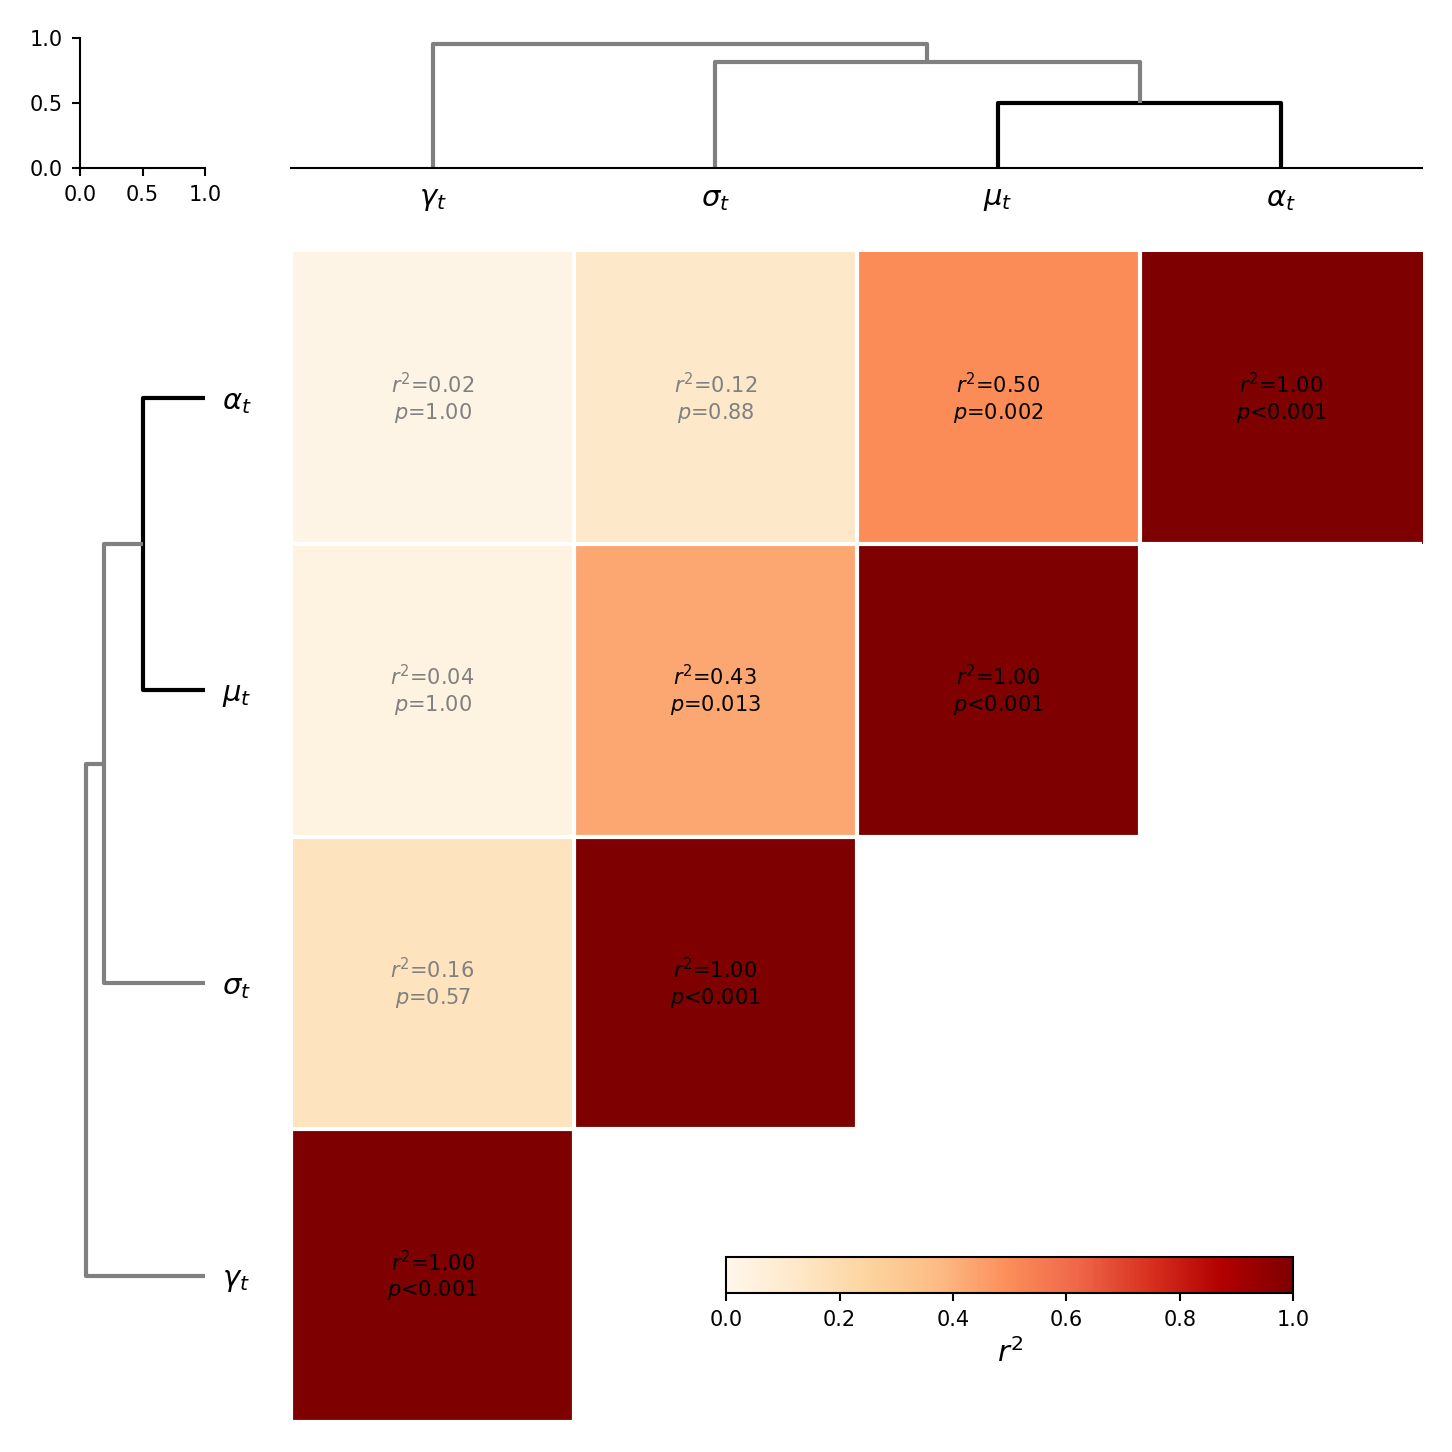

In [32]:
def FigureS11A(rvals, pvals, rsquared=True, axs=None, only_half=True, filter_t=False, filter_u=False):
    if axs is None:
        _, (_, ax_dendrogram_top, ax_dendrogram_left, ax_matrix) = plt.subplots(2, 2, figsize=(4, 4), gridspec_kw={'width_ratios': [1, 4], 'height_ratios': [1, 4]})
    else:
        ax_dendrogram_top, ax_dendrogram_left, ax_matrix = axs

    names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 
              'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']
    
    labels = {'alpha_0': r'$\alpha_0$', 'alpha_t': r"$\alpha_t$", 'alpha_u': r"$\alpha_u$",
            'gamma_0': r'$\gamma_0$', 'gamma_t': r"$\gamma_t$", 'gamma_u': r"$\gamma_u$",
            'mu_0': r'$\mu_0$', 'mu_t': r"$\mu_t$", 'mu_u': r"$\mu_u$",
            'sigma_0': r'$\sigma_0$', 'sigma_t': r"$\sigma_t$", 'sigma_u': r"$\sigma_u$"}

    assert not (filter_t and filter_u), "Cannot filter both t and u"

    if filter_t:
        names = ['alpha_t', 'gamma_t', 'mu_t', 'sigma_t']
        labels = {'alpha_t': r"$\alpha_t$", 'gamma_t': r"$\gamma_t$", 'mu_t': r"$\mu_t$", 'sigma_t': r"$\sigma_t$"}

    if filter_u:
        names = ['alpha_u', 'gamma_u', 'mu_u', 'sigma_u']
        labels = {'alpha_u': r"$\alpha_u$", 'gamma_u': r"$\gamma_u$", 'mu_u': r"$\mu_u$", 'sigma_u': r"$\sigma_u$"}


    
    # Convert pvals to a 2D array
    p_values = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            p_values[i, j] = pvals[name1][name2]

    # Convert rvals to a 2D array
    correlations = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            correlations[i, j] = rvals[name1][name2]

    print(correlations)

    # Apply Bonferroni correction
    alpha = 0.05
    num_variables = len(labels)
    num_comparisons = num_variables * (num_variables - 1) / (2 if only_half else 1)
    bonferroni_alpha = alpha / num_comparisons
    print(f'{num_comparisons} tests, Corrected alpha = {bonferroni_alpha:.4f}')
    # bonferroni_alpha = alpha
    significant_corr = p_values < bonferroni_alpha

    if rsquared:
        r = correlations.copy()
        correlations = correlations * correlations

    # Plot dendrograms
    # hierarchy.set_link_color_palette(['dodgerblue', 'orange'])
    hierarchy.set_link_color_palette(['k'])
    kwargs = {'labels':list(labels.values()), 'leaf_font_size':7, 'leaf_rotation':0, 'color_threshold':1.1, 'above_threshold_color':'gray'}
    Y = linkage(correlations, 'complete', optimal_ordering=True)
    Z2 = dendrogram(Y, orientation='top', ax=ax_dendrogram_top, **kwargs, no_plot=True)

    _plot_dendrogram(Z2["icoord"], Z2["dcoord"], Z2["ivl"], 30, 20, np.max(Z2["dcoord"]),
                    "top", False, Z2["color_list"], leaf_font_size=7, leaf_rotation=0, 
                    contraction_marks=None, above_threshold_color='gray', ax=ax_dendrogram_top)

    _plot_dendrogram(Z2["icoord"], Z2["dcoord"], Z2["ivl"], 30, 20, np.max(Z2["dcoord"]),
                    "left", False, Z2["color_list"], leaf_font_size=7, leaf_rotation=0, 
                    contraction_marks=None, above_threshold_color='gray', ax=ax_dendrogram_left)
                  
    ax_dendrogram_top.set_yticks([])
    ax_dendrogram_top.spines['left'].set_visible(False)
    ax_dendrogram_left.set_xticks([])
    ax_dendrogram_left.spines['left'].set_visible(False)
    ax_dendrogram_left.spines['bottom'].set_visible(False)


    # Plot  matrix with
    correlations = correlations[Z2['leaves'], :]
    correlations = correlations[:, Z2['leaves']]
    if only_half:
        correlations = np.tril(correlations, k=0)  # only upper triangle
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(1, 1, 1) if i == 0 else plt.cm.OrRd(i) for i in range(256)])
    im = ax_matrix.matshow(correlations, aspect='auto', origin='lower', cmap=cmap, vmin=0, vmax=1)

    for i in range(len(labels)):
        ax_matrix.axhline(i - 0.5, color='white', linewidth=1)
        ax_matrix.axvline(i - 0.5, color='white', linewidth=1)

    ax_matrix.set_xticks([])
    ax_matrix.spines['bottom'].set_visible(False)
    ax_matrix.set_yticks([])
    ax_matrix.spines['left'].set_visible(False)

    for (i, j), val in np.ndenumerate(correlations):
        color = 'gray'
        if significant_corr[Z2['leaves'][i], Z2['leaves'][j]]:
            color = 'k'
        # if i >= j:
        if (i >= j if only_half else i != j):
            _p = min(1, p_values[Z2['leaves'][i], Z2['leaves'][j]] * num_comparisons)
            _p = ''.join(stars(_p).split())
            ax_matrix.text(j, i, f"$r^2$={val:.2f}\n{_p}",
                        ha='center', va='center', color=color, fontsize=5)
    return im, num_comparisons


fig, axs = plt.subplots(2, 2, figsize=(cm2inch(12), cm2inch(12)), gridspec_kw={'width_ratios': [1, 9], 'height_ratios': [1, 9]})
_, ax_dendrogram_top, ax_dendrogram_left, ax_matrix = axs.ravel()
im, bc = FigureS11A(rvals, pvals, axs=(ax_dendrogram_top, ax_dendrogram_left, ax_matrix), filter_t=True)

axcolor = fig.add_axes([0.5, 0.1, 0.4, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')

# S11 A Correlation matrix and dendrograms between the 12 fitted model parameters capturing inter-run and run durations dynamics

66.0 tests, Corrected alpha = 0.0008


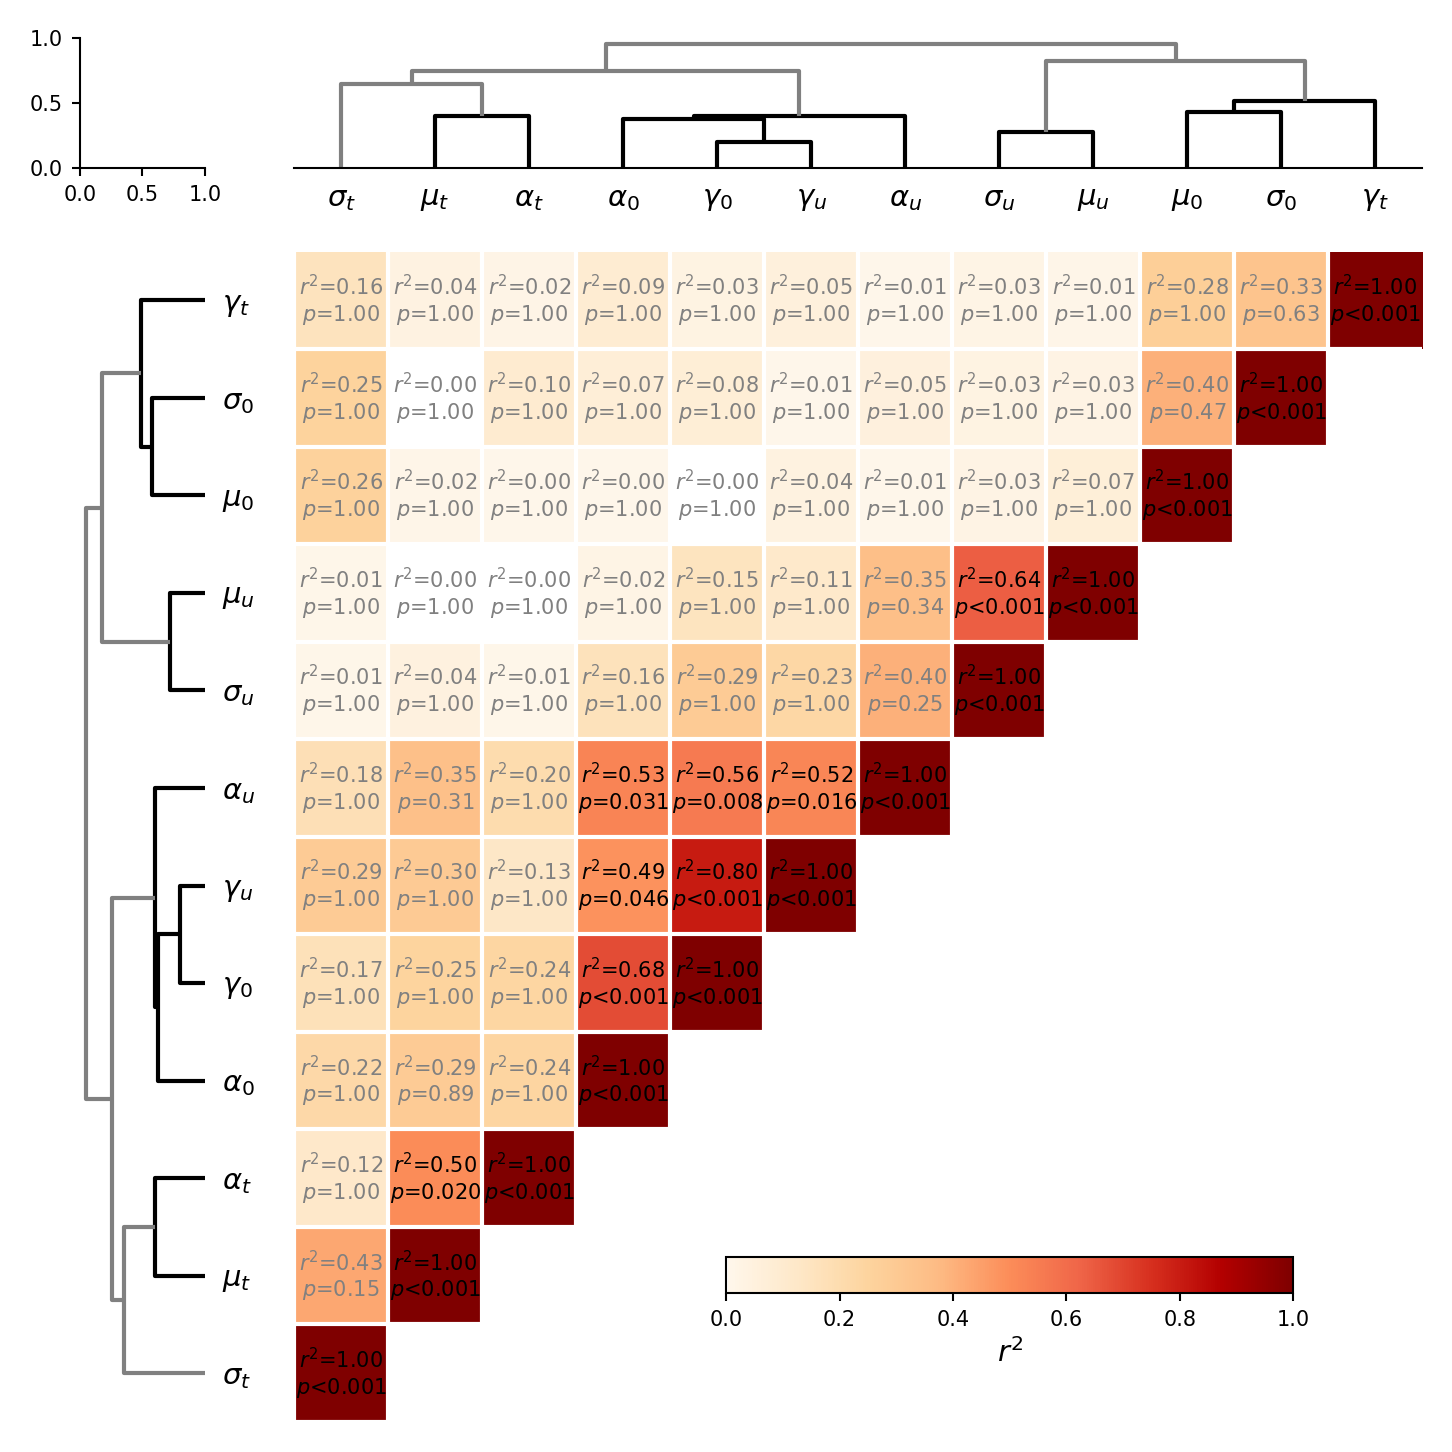

In [31]:
# correlation matrix and dendrogram.
# 2 versions: FigureS11A and Figure S11A_.
# FigureS11A_ is is the standard one, FigureS11A is the one with the hack to put mu_0 to the right
# of the dendrogram for less cluttering and better readability.

def _FigureS11A_(rvals, pvals, labels, rsquared=True, axs=None):
    if axs is None:
        _, (_, ax_dendrogram_top, ax_dendrogram_left, ax_matrix) = plt.subplots(2, 2, figsize=(4, 4), gridspec_kw={'width_ratios': [1, 4], 'height_ratios': [1, 4]})
    else:
        ax_dendrogram_top, ax_dendrogram_left, ax_matrix = axs

    names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 
              'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']
    
    # Convert pvals to a 2D array
    p_values = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            p_values[i, j] = pvals[name1][name2]

    # Convert rvals to a 2D array
    correlations = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            correlations[i, j] = rvals[name1][name2]

    # Apply Bonferroni correction
    alpha = 0.05
    num_variables = len(labels)
    num_comparisons = num_variables * (num_variables - 1) / 2
    bonferroni_alpha = alpha / num_comparisons
    print(f'{num_comparisons} tests, Corrected alpha = {bonferroni_alpha:.4f}')
    # bonferroni_alpha = alpha
    significant_corr = p_values < bonferroni_alpha

    if rsquared:
        r = correlations.copy()
        correlations = correlations * correlations

    # Plot dendrograms
    hierarchy.set_link_color_palette(['orange', 'dodgerblue'])
    kwargs = {'labels':list(labels.values()), 'leaf_font_size':7, 'leaf_rotation':0, 'color_threshold':1.1, 'above_threshold_color':'gray'}
    Y = linkage(correlations, 'complete', optimal_ordering=True)
    Z2 = dendrogram(Y, orientation='top', ax=ax_dendrogram_top, **kwargs)
    ax_dendrogram_top.set_yticks([])
    ax_dendrogram_top.spines['left'].set_visible(False)

    Z2 = dendrogram(Y, orientation='left', ax=ax_dendrogram_left, **kwargs)
    ax_dendrogram_left.set_xticks([])
    ax_dendrogram_left.spines['left'].set_visible(False)
    ax_dendrogram_left.spines['bottom'].set_visible(False)

    # Plot  matrix with
    correlations = correlations[Z2['leaves'], :]
    correlations = correlations[:, Z2['leaves']]
    correlations = correlations.T
    correlations = np.tril(correlations, k=0)  # only upper triangle
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(1, 1, 1) if i == 0 else plt.cm.OrRd(i) for i in range(256)])
    im = ax_matrix.matshow(correlations, aspect='auto', origin='lower', cmap=cmap, vmin=0, vmax=1)

    for i in range(len(labels)):
        ax_matrix.axhline(i - 0.5, color='white', linewidth=1)
        ax_matrix.axvline(i - 0.5, color='white', linewidth=1)

    ax_matrix.set_xticks([])
    ax_matrix.spines['bottom'].set_visible(False)
    ax_matrix.set_yticks([])
    ax_matrix.spines['left'].set_visible(False)

    for (i, j), val in np.ndenumerate(correlations):
        color = 'gray'
        if significant_corr[Z2['leaves'][i], Z2['leaves'][j]]:
            color = 'k'
        if i >= j:
            _p = min(1, p_values[Z2['leaves'][i], Z2['leaves'][j]] * num_comparisons)
            _p = ''.join(stars(_p).split())
            ax_matrix.text(j, i, f"$r^2$={val:.2f}\n{_p}",
                        ha='center', va='center', color=color, fontsize=5)
    return im, num_comparisons

def _FigureS11A(rvals, pvals, rsquared=True, axs=None):
    if axs is None:
        _, (_, ax_dendrogram_top, ax_dendrogram_left, ax_matrix) = plt.subplots(2, 2, figsize=(4, 4), gridspec_kw={'width_ratios': [1, 4], 'height_ratios': [1, 4]})
    else:
        ax_dendrogram_top, ax_dendrogram_left, ax_matrix = axs

    names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 
              'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']
    

    labels = {'alpha_0': r'$\alpha_0$', 'alpha_t': r"$\alpha_t$", 'alpha_u': r"$\alpha_u$",
            'gamma_0': r'$\gamma_0$', 'gamma_t': r"$\gamma_t$", 'gamma_u': r"$\gamma_u$",
            'mu_0': r'$\mu_0$', 'mu_t': r"$\mu_t$", 'mu_u': r"$\mu_u$",
            'sigma_0': r'$\sigma_0$', 'sigma_t': r"$\sigma_t$", 'sigma_u': r"$\sigma_u$"}
    
    # Convert pvals to a 2D array
    p_values = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            p_values[i, j] = pvals[name1][name2]

    # Convert rvals to a 2D array
    correlations = np.zeros((len(names), len(names)))
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            correlations[i, j] = rvals[name1][name2]

    # Apply Bonferroni correction
    alpha = 0.05
    num_variables = len(labels)
    num_comparisons = num_variables * (num_variables - 1) / 2
    bonferroni_alpha = alpha / num_comparisons
    print(f'{num_comparisons} tests, Corrected alpha = {bonferroni_alpha:.4f}')
    # bonferroni_alpha = alpha
    significant_corr = p_values < bonferroni_alpha

    if rsquared:
        r = correlations.copy()
        correlations = correlations * correlations

    # Plot dendrograms
    # hierarchy.set_link_color_palette(['dodgerblue', 'orange'])
    hierarchy.set_link_color_palette(['k'])
    kwargs = {'labels':list(labels.values()), 'leaf_font_size':7, 'leaf_rotation':0, 'color_threshold':1.1, 'above_threshold_color':'gray'}
    Y = linkage(correlations, 'complete', optimal_ordering=True)
    Z2 = dendrogram(Y, orientation='top', ax=ax_dendrogram_top, **kwargs, no_plot=True)

    _plot_dendrogram(Z2["icoord"], Z2["dcoord"], Z2["ivl"], 30, 20, np.max(Z2["dcoord"]),
                    "top", False, Z2["color_list"], leaf_font_size=7, leaf_rotation=0, 
                    contraction_marks=None, above_threshold_color='gray', ax=ax_dendrogram_top)

    _plot_dendrogram(Z2["icoord"], Z2["dcoord"], Z2["ivl"], 30, 20, np.max(Z2["dcoord"]),
                    "left", False, Z2["color_list"], leaf_font_size=7, leaf_rotation=0, 
                    contraction_marks=None, above_threshold_color='gray', ax=ax_dendrogram_left)
                  
    ax_dendrogram_top.set_yticks([])
    ax_dendrogram_top.spines['left'].set_visible(False)
    ax_dendrogram_left.set_xticks([])
    ax_dendrogram_left.spines['left'].set_visible(False)
    ax_dendrogram_left.spines['bottom'].set_visible(False)


    # Plot  matrix with
    correlations = correlations[Z2['leaves'], :]
    correlations = correlations[:, Z2['leaves']]
    correlations = np.tril(correlations, k=0)  # only upper triangle
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(1, 1, 1) if i == 0 else plt.cm.OrRd(i) for i in range(256)])
    im = ax_matrix.matshow(correlations, aspect='auto', origin='lower', cmap=cmap, vmin=0, vmax=1)

    for i in range(len(labels)):
        ax_matrix.axhline(i - 0.5, color='white', linewidth=1)
        ax_matrix.axvline(i - 0.5, color='white', linewidth=1)

    ax_matrix.set_xticks([])
    ax_matrix.spines['bottom'].set_visible(False)
    ax_matrix.set_yticks([])
    ax_matrix.spines['left'].set_visible(False)

    for (i, j), val in np.ndenumerate(correlations):
        color = 'gray'
        if significant_corr[Z2['leaves'][i], Z2['leaves'][j]]:
            color = 'k'
        if i >= j:
        # if i != j:
            _p = min(1, p_values[Z2['leaves'][i], Z2['leaves'][j]] * num_comparisons)
            _p = ''.join(stars(_p).split())
            ax_matrix.text(j, i, f"$r^2$={val:.2f}\n{_p}",
                        ha='center', va='center', color=color, fontsize=5)
    return im, num_comparisons


fig, axs = plt.subplots(2, 2, figsize=(cm2inch(12), cm2inch(12)), gridspec_kw={'width_ratios': [1, 9], 'height_ratios': [1, 9]})
_, ax_dendrogram_top, ax_dendrogram_left, ax_matrix = axs.ravel()
im, bc = FigureS11A(rvals, pvals, axs=(ax_dendrogram_top, ax_dendrogram_left, ax_matrix))

axcolor = fig.add_axes([0.5, 0.1, 0.4, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')

# Figure S11: Correlations between all model parameters describing inter-run and run durations modulations during sessions and across actions costs

66.0 tests, Corrected alpha = 0.0008


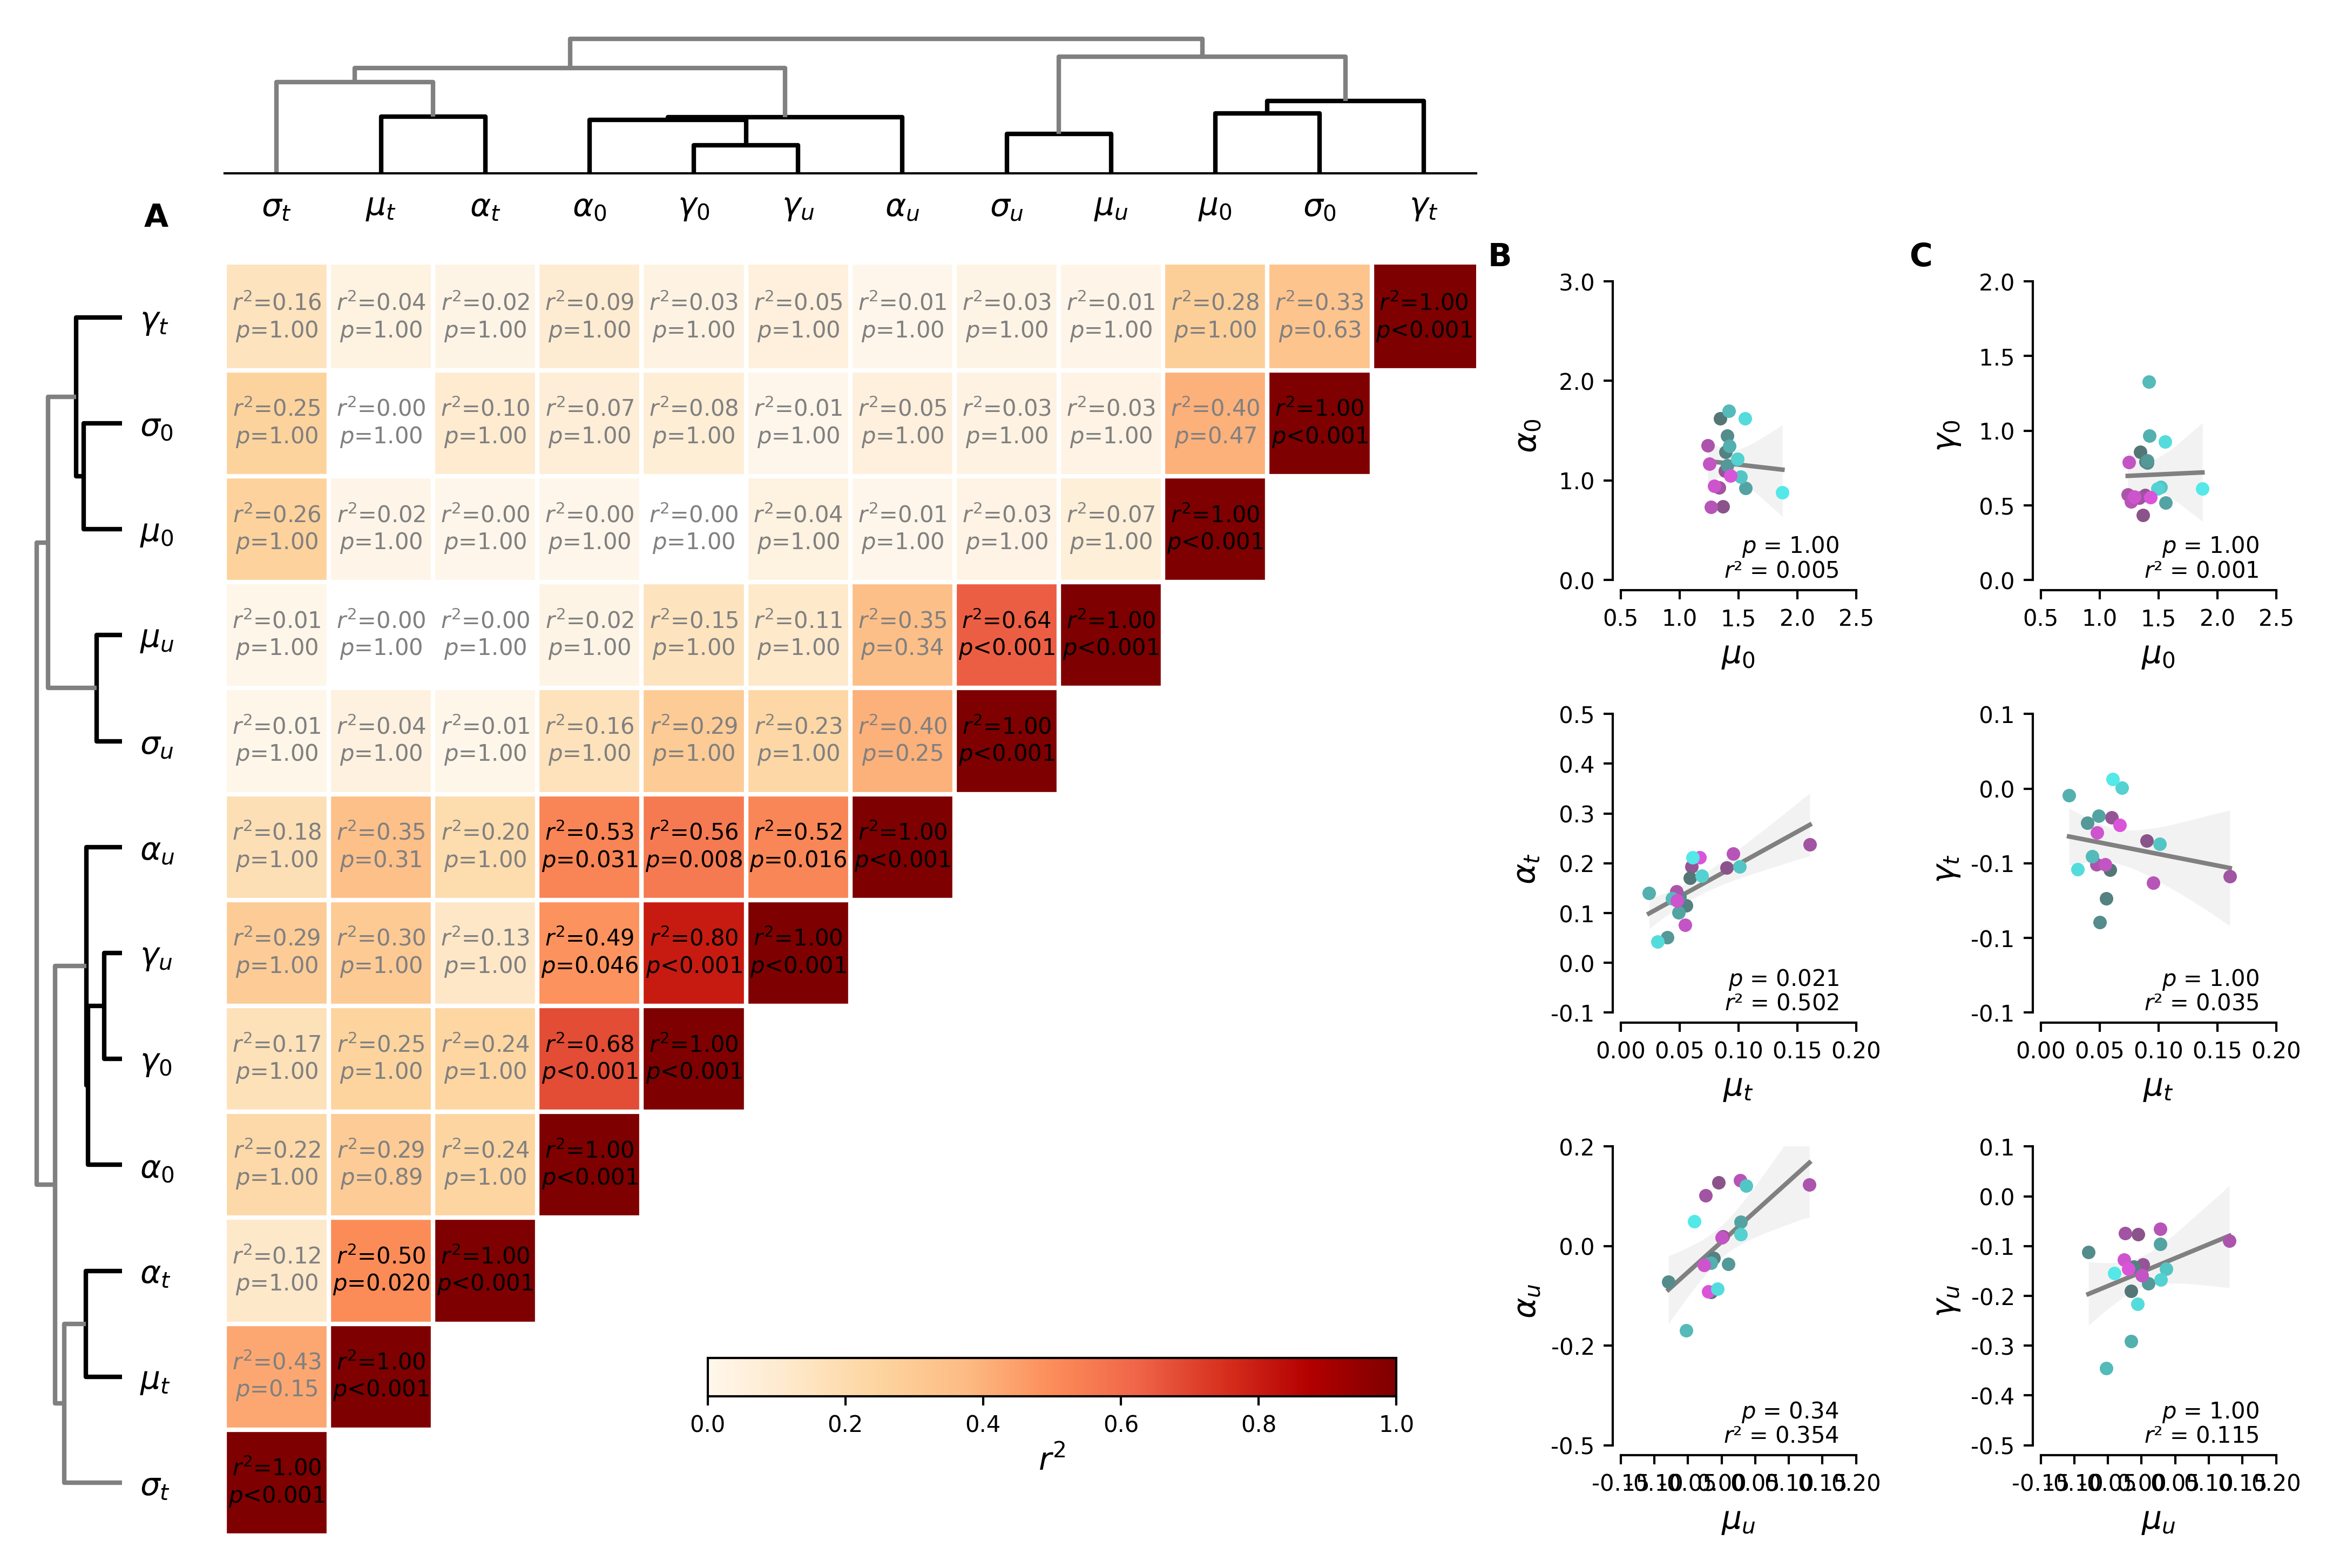

In [ ]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(12)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(1, 3, width_ratios=[1.8, .01, 1])

left = gs0[0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_top = plt.subplot(left[0, 1])
dendrogram_left_top = plt.subplot(left[1, 0])
matrix = plt.subplot(left[1, 1])

right = gs0[2].subgridspec(4, 2, width_ratios=[1, 1], height_ratios=[6, 9, 9, 9])
blk = plt.subplot(right[0, 1]).axis('off')
blk_ = plt.subplot(right[0, 0]).axis('off')
mu_0_alpha_0 = plt.subplot(right[1, 0])
mu_t_alpha_t = plt.subplot(right[2, 0])
mu_u_alpha_u = plt.subplot(right[3, 0])

mu_0_gamma_0 = plt.subplot(right[1, 1])
mu_t_gamma_t = plt.subplot(right[2, 1])
mu_u_gamma_u = plt.subplot(right[3, 1])

im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_top, dendrogram_left_top, matrix))
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')
Figure6K(mu_0, alpha_0, 'mu_0', 'alpha_0', ax=mu_0_alpha_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
Figure6K(mu_u, alpha_u, 'mu_u', 'alpha_u', ax=mu_u_alpha_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

Figure6K(mu_0, gamma_0, 'mu_0', 'gamma_0', ax=mu_0_gamma_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
Figure6K(mu_t, gamma_t, 'mu_t', 'gamma_t', ax=mu_t_gamma_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
Figure6K(mu_u, gamma_u, 'mu_u', 'gamma_u', ax=mu_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

axes = fig.get_axes()
for ax in axes[5:]:
    ax.yaxis.set_major_formatter('{x:>4.1f}')


add_all_letters([mu_0_alpha_0, mu_0_gamma_0], ["B", "C"])
add_one_letter(dendrogram_top_top, "A", x=0.065, y=.86)

# plt.savefig("./Figures_paper/Figure_S11.pdf", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

# plt.savefig("./Figures_paper/Figure_S11.svg", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

[[ 1.          0.14180253  0.70870547  0.34696441]
 [ 0.14180253  1.         -0.18764014 -0.39525552]
 [ 0.70870547 -0.18764014  1.          0.65475405]
 [ 0.34696441 -0.39525552  0.65475405  1.        ]]
6.0 tests, Corrected alpha = 0.0083
[[1.         0.72211196 0.59480127 0.63570234]
 [0.72211196 1.         0.33852605 0.47799854]
 [0.59480127 0.33852605 1.         0.80035424]
 [0.63570234 0.47799854 0.80035424 1.        ]]
6.0 tests, Corrected alpha = 0.0083


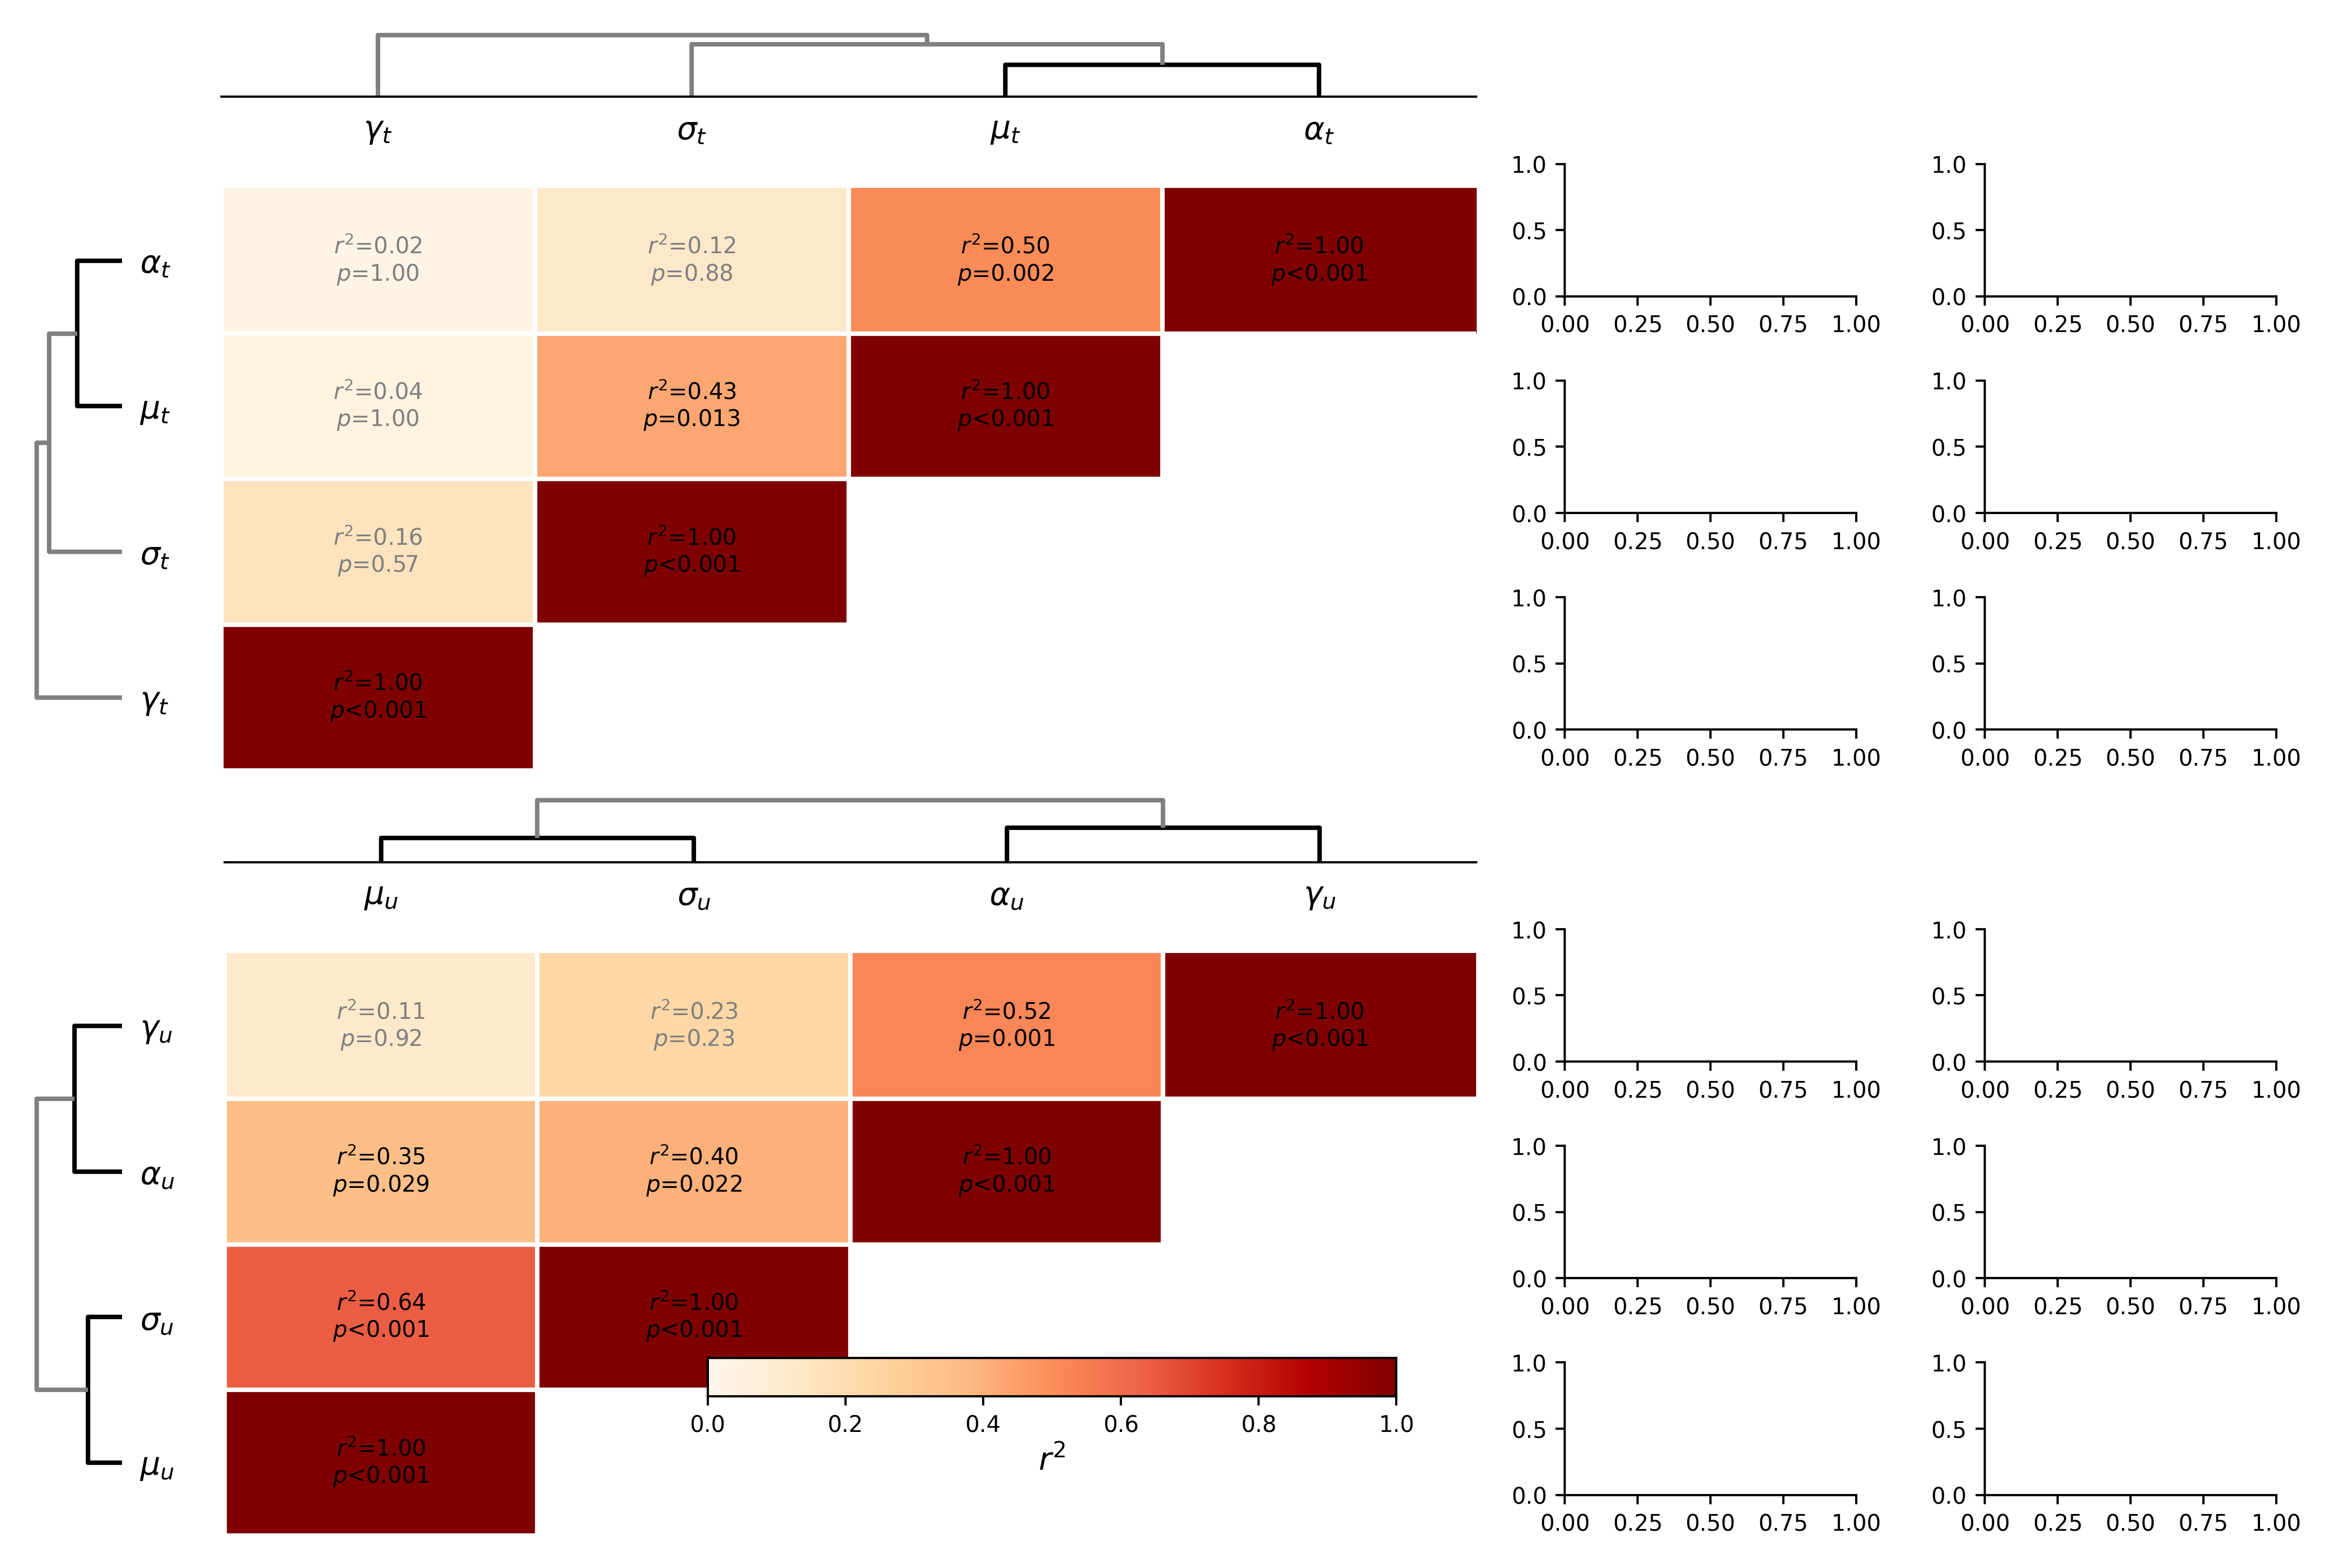

In [33]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(12)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(2, 3, width_ratios=[1.8, .01, 1])

topleft = gs0[0, 0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_top = plt.subplot(topleft[0, 1])
dendrogram_left_top = plt.subplot(topleft[1, 0])
matrix_top = plt.subplot(topleft[1, 1])

topright = gs0[0, 2].subgridspec(4, 2, width_ratios=[1, 1], height_ratios=[6, 9, 9, 9])
blk = plt.subplot(topright[0, 1]).axis('off')
blk_ = plt.subplot(topright[0, 0]).axis('off')
mu_0_alpha_0 = plt.subplot(topright[1, 0])
mu_t_alpha_t = plt.subplot(topright[2, 0])
mu_u_alpha_u = plt.subplot(topright[3, 0])

mu_0_gamma_0 = plt.subplot(topright[1, 1])
mu_t_gamma_t = plt.subplot(topright[2, 1])
mu_u_gamma_u = plt.subplot(topright[3, 1])
im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_top, dendrogram_left_top, matrix_top), filter_t=True)
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')
# Figure6K(mu_0, alpha_0, 'mu_0', 'alpha_0', ax=mu_0_alpha_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, alpha_u, 'mu_u', 'alpha_u', ax=mu_u_alpha_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

# Figure6K(mu_0, gamma_0, 'mu_0', 'gamma_0', ax=mu_0_gamma_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, gamma_t, 'mu_t', 'gamma_t', ax=mu_t_gamma_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, gamma_u, 'mu_u', 'gamma_u', ax=mu_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)


botleft = gs0[1, 0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_bot = plt.subplot(botleft[0, 1])
dendrogram_left_bot = plt.subplot(botleft[1, 0])
matrix_bot = plt.subplot(botleft[1, 1])
im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_bot, dendrogram_left_bot, matrix_bot), filter_u=True)
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')

botright = gs0[1, 2].subgridspec(4, 2, width_ratios=[1, 1], height_ratios=[6, 9, 9, 9])
blk = plt.subplot(botright[0, 1]).axis('off')
blk_ = plt.subplot(botright[0, 0]).axis('off')
mu_0_alpha_0 = plt.subplot(botright[1, 0])
mu_t_alpha_t = plt.subplot(botright[2, 0])
mu_u_alpha_u = plt.subplot(botright[3, 0])

mu_0_gamma_0 = plt.subplot(botright[1, 1])
mu_t_gamma_t = plt.subplot(botright[2, 1])
mu_u_gamma_u = plt.subplot(botright[3, 1])

# axes = fig.get_axes()
# for ax in axes[5:]:
#     ax.yaxis.set_major_formatter('{x:>4.1f}')


# add_all_letters([mu_0_alpha_0, mu_0_gamma_0], ["B", "C"])
# add_one_letter(dendrogram_top_top, "A", x=0.065, y=.86)

# plt.savefig("./Figures_paper/Figure_S11.pdf", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

# plt.savefig("./Figures_paper/Figure_S11.svg", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

[[ 1.          0.14180253  0.70870547  0.34696441]
 [ 0.14180253  1.         -0.18764014 -0.39525552]
 [ 0.70870547 -0.18764014  1.          0.65475405]
 [ 0.34696441 -0.39525552  0.65475405  1.        ]]
6.0 tests, Corrected alpha = 0.0083
[[1.         0.72211196 0.59480127 0.63570234]
 [0.72211196 1.         0.33852605 0.47799854]
 [0.59480127 0.33852605 1.         0.80035424]
 [0.63570234 0.47799854 0.80035424 1.        ]]
6.0 tests, Corrected alpha = 0.0083


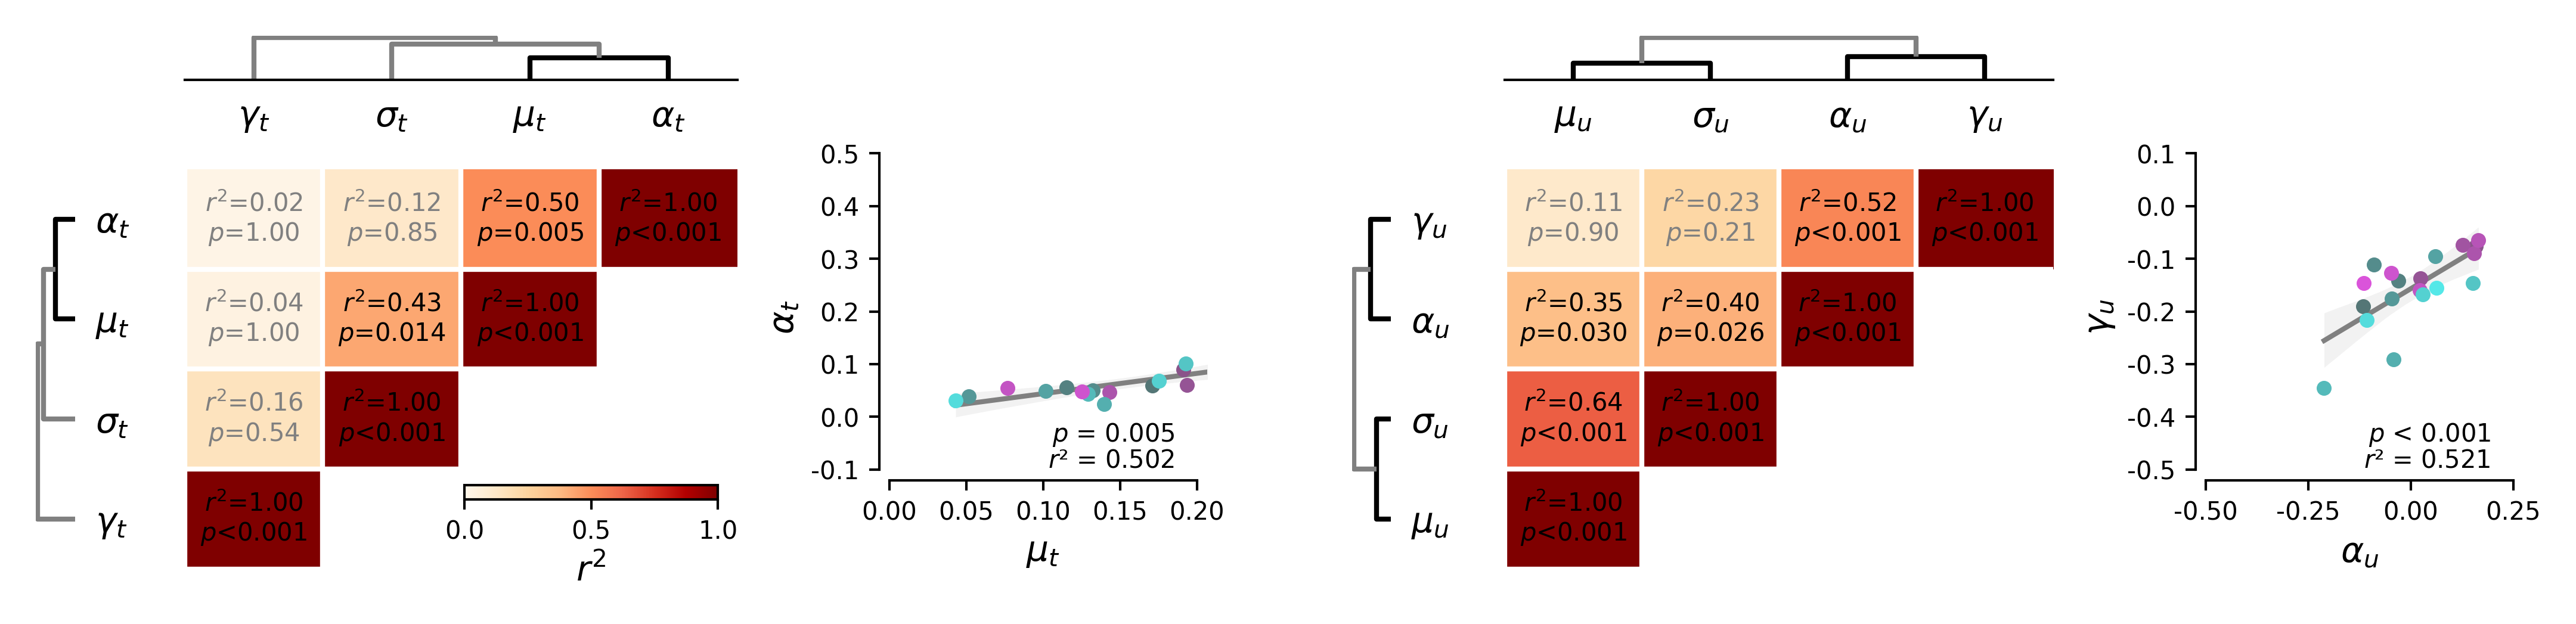

In [54]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(4)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(1, 5, width_ratios=[1.5, 1, 0.2, 1.5, 1])

topleft = gs0[0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_top = plt.subplot(topleft[0, 1])
dendrogram_left_top = plt.subplot(topleft[1, 0])
matrix_top = plt.subplot(topleft[1, 1])

topright = gs0[1].subgridspec(2, 1, height_ratios=[6, 27])
blk_ = plt.subplot(topright[0, 0]).axis('off')
mu_t_alpha_t = plt.subplot(topright[1, 0])

im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_top, dendrogram_left_top, matrix_top), filter_t=True)
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')
Figure6K(alpha_t, mu_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

# Figure6K(mu_0, alpha_0, 'mu_0', 'alpha_0', ax=mu_0_alpha_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, alpha_u, 'mu_u', 'alpha_u', ax=mu_u_alpha_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

# Figure6K(mu_0, gamma_0, 'mu_0', 'gamma_0', ax=mu_0_gamma_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, gamma_t, 'mu_t', 'gamma_t', ax=mu_t_gamma_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, gamma_u, 'mu_u', 'gamma_u', ax=mu_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)


botleft = gs0[3].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_bot = plt.subplot(botleft[0, 1])
dendrogram_left_bot = plt.subplot(botleft[1, 0])
matrix_bot = plt.subplot(botleft[1, 1])
im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_bot, dendrogram_left_bot, matrix_bot), filter_u=True)
axcolor = fig.add_axes([0.175, 0.15, 0.1, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')

botright = gs0[4].subgridspec(2, 1, height_ratios=[6, 27])
blk_ = plt.subplot(botright[0, 0]).axis('off')
alpha_u_gamma_u = plt.subplot(botright[1, 0])
Figure6K(alpha_u, gamma_u, 'alpha_u', 'gamma_u', ax=alpha_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)


# axes = fig.get_axes()
# for ax in axes[5:]:
#     ax.yaxis.set_major_formatter('{x:>4.1f}')


# add_all_letters([mu_0_alpha_0, mu_0_gamma_0], ["B", "C"])
# add_one_letter(dendrogram_top_top, "A", x=0.065, y=.86)

plt.savefig("./Figures_paper/Figure_S11120.pdf", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_S11120.svg", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

[[ 1.          0.14180253  0.70870547  0.34696441]
 [ 0.14180253  1.         -0.18764014 -0.39525552]
 [ 0.70870547 -0.18764014  1.          0.65475405]
 [ 0.34696441 -0.39525552  0.65475405  1.        ]]
6.0 tests, Corrected alpha = 0.0083
[[1.         0.72211196 0.59480127 0.63570234]
 [0.72211196 1.         0.33852605 0.47799854]
 [0.59480127 0.33852605 1.         0.80035424]
 [0.63570234 0.47799854 0.80035424 1.        ]]
6.0 tests, Corrected alpha = 0.0083


(0.000247999504000992, 0.7221119600685664)

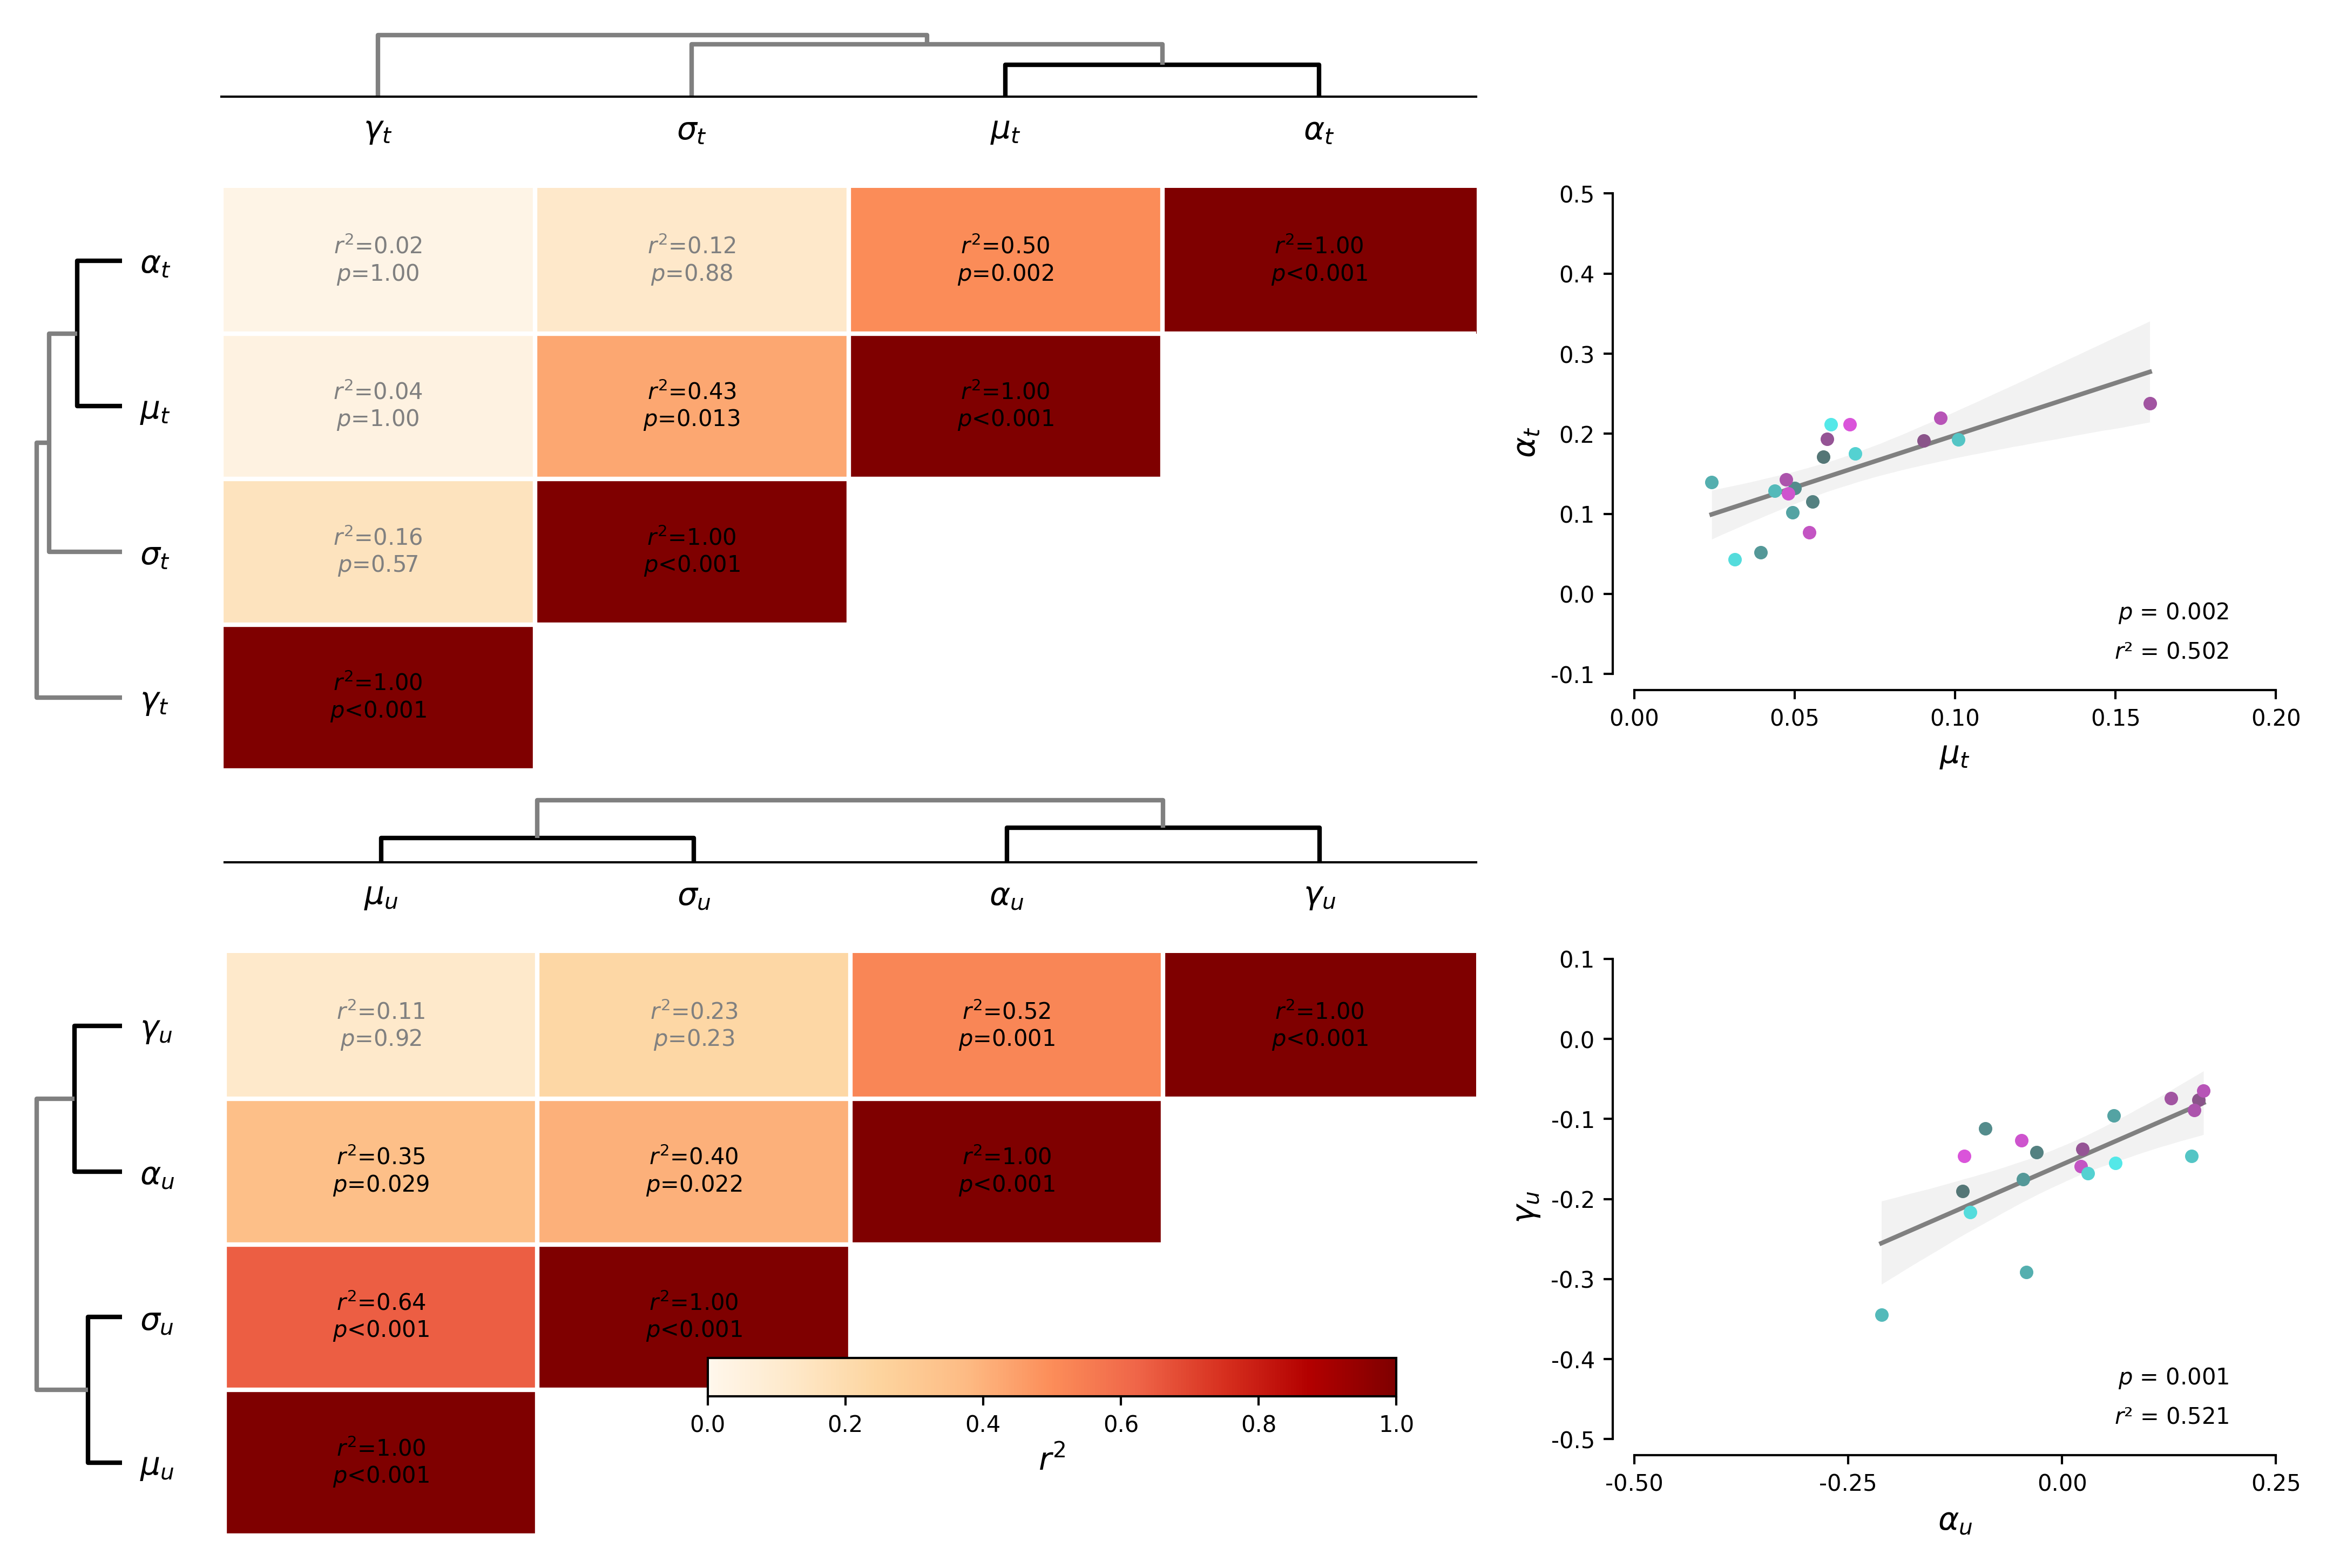

In [52]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(12)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(2, 3, width_ratios=[1.8, .01, 1])

topleft = gs0[0, 0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_top = plt.subplot(topleft[0, 1])
dendrogram_left_top = plt.subplot(topleft[1, 0])
matrix_top = plt.subplot(topleft[1, 1])

topright = gs0[0, 2].subgridspec(2, 1, height_ratios=[6, 27])
blk_ = plt.subplot(topright[0, 0]).axis('off')
mu_t_alpha_t = plt.subplot(topright[1, 0])

im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_top, dendrogram_left_top, matrix_top), filter_t=True)
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')
Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

# Figure6K(mu_0, alpha_0, 'mu_0', 'alpha_0', ax=mu_0_alpha_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, alpha_t, 'mu_t', 'alpha_t', ax=mu_t_alpha_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, alpha_u, 'mu_u', 'alpha_u', ax=mu_u_alpha_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)

# Figure6K(mu_0, gamma_0, 'mu_0', 'gamma_0', ax=mu_0_gamma_0, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_t, gamma_t, 'mu_t', 'gamma_t', ax=mu_t_gamma_t, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)
# Figure6K(mu_u, gamma_u, 'mu_u', 'gamma_u', ax=mu_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)


botleft = gs0[1, 0].subgridspec(2, 2, height_ratios=[1, 9], width_ratios=[1, 14])
dendrogram_top_bot = plt.subplot(botleft[0, 1])
dendrogram_left_bot = plt.subplot(botleft[1, 0])
matrix_bot = plt.subplot(botleft[1, 1])
im, bc = FigureS11A(rvals, pvals, axs=(dendrogram_top_bot, dendrogram_left_bot, matrix_bot), filter_u=True)
axcolor = fig.add_axes([0.3, 0.1, 0.3, 0.025])
plt.colorbar(im, cax=axcolor, orientation='horizontal', label='$r^2$')

botright = gs0[1, 2].subgridspec(2, 1, height_ratios=[6, 27])
blk_ = plt.subplot(botright[0, 0]).axis('off')
alpha_u_gamma_u = plt.subplot(botright[1, 0])
Figure6K(alpha_u, gamma_u, 'alpha_u', 'gamma_u', ax=alpha_u_gamma_u, animal_list=intact_rats, bonferroni_correction=bc, force_p=pvals)


# axes = fig.get_axes()
# for ax in axes[5:]:
#     ax.yaxis.set_major_formatter('{x:>4.1f}')


# add_all_letters([mu_0_alpha_0, mu_0_gamma_0], ["B", "C"])
# add_one_letter(dendrogram_top_top, "A", x=0.065, y=.86)

# plt.savefig("./Figures_paper/Figure_S11.pdf", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

# plt.savefig("./Figures_paper/Figure_S11.svg", facecolor='w', 
#                 edgecolor='none', bbox_inches='tight', format="svg", dpi=600)